<a href="https://colab.research.google.com/github/shahdelmasry12/AI-Machine-Learning-MSP/blob/main/NLP_Projects/NLP_Sentiment__Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **About Dataset**
🧠 Dataset Details

  * Size: 241,000+ English-language comments
  * Labels:
    * 0 → Negative
    * 1 → Neutral
    *  2 → Positive




# **Upload Data & Importing libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

#NLP
import nltk
from nltk.tokenize import word_tokenize # to split into word tokenize
from nltk.corpus import stopwords # “the,” “and,” “is,” “in,” “for,” “where,” “when,...
from nltk.stem import WordNetLemmatizer
#ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

#Download NLTK Resources
nltk.download('punkt',      quiet=True) # Download the 'punkt' tokenizer data
nltk.download('punkt_tab',  quiet=True) # Download the 'punkt_tab' tokenizer data, as suggested by the error
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
url="https://raw.githubusercontent.com/shahdelmasry12/AI-Machine-Learning-MSP/refs/heads/main/NLP_Projects/sentiment_data.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


# **EDA(Exploratory Data Analysis)**


In [2]:
df.shape

(241145, 3)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


In [4]:
# check Missing Value
df.isnull().sum()

,0
Unnamed: 0,0
Comment,217
Sentiment,0


In [5]:
# Drop Na Values
df.dropna(inplace=True)
#check Missing Value
df.isnull().sum()

,0
Unnamed: 0,0
Comment,0
Sentiment,0


In [6]:
# Delete Unnamed column
df.drop('Unnamed: 0',axis=1,inplace=True)# axis=1 ---> columns
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [7]:
#To get the number of unique values for each Column
df.nunique()

,0
Comment,214157
Sentiment,3


Sentiment
2    0.427705
1    0.343576
0    0.228720
Name: proportion, dtype: float64


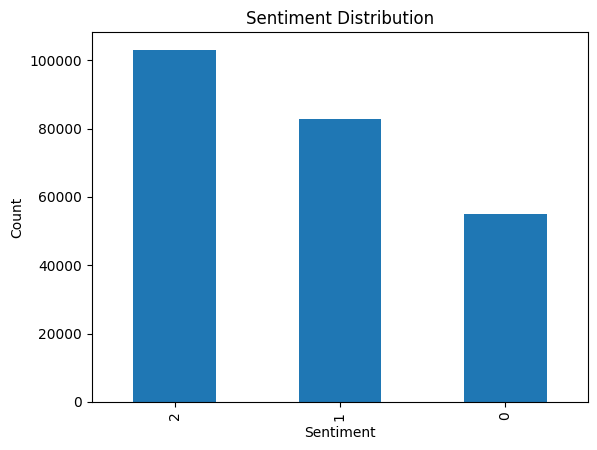

In [8]:
# Calculate the percentage for each Sentiment value(target)
print(df.Sentiment.value_counts(normalize=True))
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### **Define comment and label varaibles**

In [9]:
comment=df.drop(columns=['Sentiment'])
label=df['Sentiment']

comment.head()

,Comment
0,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...
2,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...
4,apple pay convenient secure easy use used kore...


# **Cleaning and Preprocessing Text**

In [10]:
# Initialize the lemmatizer
lm = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))
# Initialize an empty list to store the cleaned comment
comment_cleaned =[]
# Reset the index of the 'comment' DataFrame to ensure a continuous integer index
# This is necessary because dropna() earlier might have left gaps in the index,
# causing KeyError when accessing by integer position `i` in the loop.
comment_processed = comment.reset_index(drop=True)

# Loop through each comment in the 'comment_processed' DataFrame
for i in range(len(comment_processed)):
    # Remove non-alphanumeric characters from the comment title using regex
    single_comment = re.sub('[^a-zA-Z0-9]', ' ', str(comment_processed['Comment'][i]))

    # Convert the to lowercase
    single_comment = single_comment.lower()

    # Split the comments into individual words
    single_comment_word_tokens = word_tokenize(single_comment)

    # Lemmatize, stem each word, and remove stopwords
    single_comment_word_tokens= [lm.lemmatize(x) for x in  single_comment_word_tokens if x not in STOP_WORDS and len(x) > 1]   #[call, ]

    # Join the list of words back into a single string
    cleaned_single_comment = " ".join(single_comment_word_tokens)

    # Append the cleaned message to the corpus list
    comment_cleaned.append(cleaned_single_comment)

# **TF-IDF Vectorization**

In [11]:
# ── TF-IDF ────────────────────────────────────────────────────────
# max_features=10000  → keep top 10k most informative terms
# ngram_range=(1,2)   → include bigrams for better context
# min_df=2            → ignore very rare terms (noise)
# sublinear_tf=True   → apply log normalization
tf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
x=tf.fit_transform(comment_cleaned)

In [12]:
x[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 33 stored elements and shape (1, 20000)>

In [16]:
x[:5]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 110 stored elements and shape (5, 20000)>

# **Modeling**

## Splitting into train and test sets

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(x,label,test_size=0.2,random_state=42,stratify=label)# stratify=label --> to balance classes

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7882372473332503

Report:
               precision    recall  f1-score   support

           0       0.79      0.66      0.72     11021
           1       0.74      0.83      0.78     16556
           2       0.83      0.82      0.83     20609

    accuracy                           0.79     48186
   macro avg       0.79      0.77      0.78     48186
weighted avg       0.79      0.79      0.79     48186


Confusion Matrix:
 [[ 7275  2177  1569]
 [  963 13721  1872]
 [  997  2626 16986]]
